# Session 1 — Introduction, CMS Data, and Coffea Basics

This is the first part of the **CMS DAS bbMET analysis exercise**. In this session we connect the physics motivation from the CMS search for dark matter produced with bottom quarks (bb + MET) to the concrete data format (NanoAOD) and tools (Coffea) that we will use in the following sessions.

**Learning objectives:**
- Understand dark matter collider searches, with a focus on **bb + MET** final states
- Understand CMS data formats and NanoAOD, and how they encode jets, b-jets, leptons, and MET
- Load data using Coffea and explore event content in a bbMET-style analysis
- Produce basic kinematic plots (jets, leptons, MET) that appear in the full analysis


> For context, many of the concepts here are used in the CMS bb + MET analysis documented in JHEP 02 (2025) 050. We only implement a simplified version suitable for a hands-on exercise.


---
## 1. Introduction to Dark Matter

In the standard cosmological picture, **dark matter constitutes about 27% of the Universe**. There are clear evidences from cosmology and astrophysics, for example:
- **Galaxy rotation curves**
- **Gravitational lensing**
- **Cosmic microwave background (CMB)**

**Goal:** understand the origin/nature of dark matter (DM).

Cosmological measurements (e.g. Planck) tell us that about **26%** of the energy density of the universe is in the form of **dark matter (DM)**. Evidence comes from galaxy rotation curves, gravitational lensing, and the cosmic microwave background, but we do not yet know the particle nature of DM.

<p align="center">
  <img src="figures/session1_fig_dm_pie_rotation_curve_gravitational_lensing.png" alt="Dark matter energy budget, Galaxy rotation curve evidence and Gravitational lensing evidence" style="width: 75%; height: auto;"/>
</p>

### Methods to search for dark matter

<div style="display: flex; gap: 1.5rem; align-items: flex-start;">
  <div style="flex: 0 0 55%; max-width: 55%;">

- **Direct detection**: observe low-energy nuclear recoils in underground detectors, induced by dark matter particles that pass through the Earth.
- **Indirect detection**: search in outer space for Standard Model particles produced in the self-annihilation or decay of dark matter.
- **Collider searches**: produce DM in the laboratory. Dark matter particles escape the detector unseen and must recoil against Standard Model particles to become "visible" via missing transverse energy.

  </div>

  <div style="flex: 0 0 40%; max-width: 40%; text-align: center;">
    <img src="figures/session1_fig_dm_detection_methods.png" alt="Direct, indirect, and collider dark matter searches" style="width: 50%; height: auto;"/>
  </div>
</div>

A broad class of models assumes **weakly interacting massive particles (WIMPs)** with masses of a few GeV–TeV. If such particles couple to quarks or gluons, they can be **produced at the LHC**. Because they are neutral and weakly interacting, they traverse the detector, leading to an apparent imbalance in the transverse momentum of visible particles.

At colliders like the LHC we therefore search for DM by looking for **large missing transverse energy (MET)**, often written as \(p_T^{\text{miss}}\), recoiling against visible objects such as jets or leptons. In this CMS DAS exercise we focus on the case where the DM is produced together with a **pair of bottom quarks (bb)**, leading to a **bb + MET** final state.

### Why colliders?

- We can produce DM in the lab if it couples to quarks, gluons, or electroweak particles.
- The experimental signature is **MET** (imbalance in transverse momentum) when DM particles leave the detector.
- Heavy-flavor jets (b-jets) are important in many models (e.g. the **2HDM+a** benchmark used in the CMS bb + MET analysis) where the mediator couples preferentially to the Higgs sector and to bottom quarks.

### Types of dark matter searches in Colliders

- **Mediator-based searches**: dark matter is produced via a new mediator. The mediator can also decay to Standard Model particles, enabling **resonance searches** (bump hunts), e.g. in the **dijet invariant mass** spectrum.
- **Mon-X searches**: **mono-X** signatures are a visible object recoiling against missing energy, where **X** can be **photons**, **W/Z**, or **jets**.
- **Higgs sector**: dark matter produced in the **decay of the Higgs boson**.

<p align="center">
  <img src="figures/session1_fig_cms_dm_search_types.png" alt="CMS dark matter search categories" style="width: 80%; height: auto;"/>
</p>

- bb + MET searches are **complementary** to other X + MET channels (monojet, mono-Z, tt̄ + MET, etc.), probing regions of parameter space with large couplings to b quarks and high values of \(\tan\beta\).

In this DAS exercise we will not implement the full model, but we will reproduce the main **analysis ingredients** used in such a search: defining physics objects, selecting a signal-like region, and inspecting key distributions such as MET.

### Signal process (simplified)

We consider a simplified process inspired by the **2HDM+a** model used in the CMS analysis:

$$pp \to b\bar{b} + \chi\bar{\chi}$$

where ($\chi$) is the dark matter particle (invisible). In 2HDM+a, the interaction proceeds via additional scalar and pseudoscalar bosons; their couplings to bottom quarks are enhanced at large ($\tan\beta$), making **bb + MET** a powerful channel.

<p align="center">
  <img src="figures/session1_fig_feynman_bbmet.png" alt="2HDM+a bb + DM Feynman diagrams" style="width: 60%; height: auto;"/>
</p>

**Experimental signature:**
- Two or more **b-jets**, originating from bottom quarks
- Large **MET**, carried away by the DM particles
- **No isolated leptons**, to suppress W+jets and semileptonic tt̄ backgrounds

Later in the exercise you will build selections that move from a loose bb + jets sample towards a **signal region** resembling that used in the full analysis.



---
## 2. Dark Matter Searches at CMS- $b\bar{b}+MET(p_{T}^{miss})$ 

On of the main type of DM searches is often summarised as **X + MET** signatures, where X is one or more visible objects (jets, photons, W/Z bosons, top quarks, …) and MET is carried by invisible particles (DM or neutrinos).

In the **bb + MET** channel:

| Observable | Role |
|-----------|------|
| **MET** | Indicates invisible particles carrying away momentum (DM + neutrinos) |
| **b-jets** | Tag production in association with bottom quarks; enhanced in high-($\tan\beta$) 2HDM+a scenarios |
| **Lepton veto** | Reduces W+jets and semileptonic $t\bar{t}$, where a charged lepton is present |

**Main backgrounds in a realistic bbMET analysis:**

<div style="display: flex; gap: 1.5rem; align-items: flex-start;">
  <div style="flex: 0 0 50%; max-width: 50%;">

- **Z($→\nu\bar{\nu}$) + jets**, especially with b-jets: genuine MET from neutrinos, dominant at high MET.
- **$t\bar{t}$** and **single-top**: b-jets + MET from W $→\ell\nu$; reduced by lepton veto but still important.
- **W($→\ell\nu$) + jets**: MET from W $→\ell\nu$; strongly reduced by the lepton veto.

  </div>

  <div style="flex: 0 0 45%; max-width: 45%; text-align: left;">
    <img src="figures/session1_fig_major_backgrounds.png" alt="Some of the major backgrounds for bb + MET" style="width: 80%; height: auto; margin-left: 0;"/>
  </div>
</div>

In this DAS exercise we focus on the **object-level ingredients and simple selections** that these full analyses rely on; full background estimation and fits come in later sessions.


---
## 3. Overview of the Large Hadron Collider (LHC) & Compact Muon Solenoid (CMS) Detector

The Large Hadron Collider is the world’s largest and most powerful particle accelerator, featuring:

- **27 km circular tunnel** — accelerates and collides proton beams at unprecedented energies.
- **Superconducting magnet system** — ~1232 dipole magnets bend the beams and ~392 quadrupole magnets focus them.
- **Ultra-high vacuum beam pipe** — maintains pressures far below atmospheric levels to ensure clean collisions.
- **Cryogenic system (1.9 K)** — uses superfluid helium to keep magnets superconducting.

<p align="center">
  <img src="figures/session1_fig_lhc.png" alt="Large Hadron Collider (LHC)" style="width: 75%; height: auto;"/>
</p>



CMS is a general-purpose detector at the LHC built around a **superconducting solenoid** (3.8 T) with:
- **Silicon tracker** — measures charged-particle trajectories and momenta.
- **Electromagnetic calorimeter (ECAL)** — measures energies of electrons and photons.
- **Hadron calorimeter (HCAL)** — measures hadronic energy (jets).
- **Muon system** — identifies and measures muons outside the solenoid.

<p align="center">
  <img src="figures/session1_fig_cms_detector.png" alt="CMS detector" style="width: 75%; height: auto;"/>
</p>


In modern CMS analyses, events are reconstructed with the **particle-flow (PF)** algorithm, which combines information from all subsystems into a list of PF candidates (charged hadrons, neutral hadrons, photons, electrons, muons). From these, we build:
- **Jets** (clustered PF candidates)
- **b-tagged jets** (jets tagged as likely containing a b hadron)
- **Leptons** (electrons, muons, taus)
- **MET** (negative vector sum of PF candidates in the transverse plane)

Neutrinos (and DM) do not leave direct signals, so an imbalance in the PF candidates’ transverse momentum defines **MET**, our main handle on invisible particles.

*Discussion:* Why can’t we "see" dark matter in the detector, and why is MET only defined in the transverse plane (not along the beam)?

---
## 4. CMS Data Formats

CMS stores collision data and simulation in **ROOT** files. The following processing levels define the data hierarchy:

* **RAW** – Original detector data directly from the readout system.
    * (~0.5–2 MB per event; depends on pileup and detector conditions)
* **AOD** (Analysis Object Data) – Fully reconstructed physics objects such as tracks and jets.
    * (~200–400 kB per event)
* **MiniAOD** – Streamlined format with high-level objects and essential information for most analyses.
    * (~40–100 kB per event)
* **NanoAOD** – Highly compact flat ntuple format containing only the most commonly used variables.
    * (~1–5 kB per event; analysis-dependent)


### Analysis Strategy
We will use **NanoAOD** because it is extremely small, fast to process, and well-suited for large-scale analysis workflows (e.g., with **Coffea**).

---
## 5. What is NanoAOD?

NanoAOD is a compact, flat ntuple format designed for high-level physics analysis. It provides the following core content:

* **Jets** – Kinematics ($p_T, \eta, \phi$, mass), b-tagging discriminants, and identification (ID) flags.
* **MET** – Missing Transverse Energy magnitude ($p_T$) and azimuthal angle ($\phi$).
* **Electrons & Muons** – Precision kinematics, identification (ID), and isolation variables.
* **Photons & Taus** – Standard reconstructed candidates with associated quality criteria.
* **Triggers & Generator Info** – L1/HLT trigger bits and Monte Carlo (MC) truth information for simulation.

### Data Access & Syntax
Branch names in the ROOT files follow a consistent `Object_variable` pattern (e.g., `Jet_pt`, `MET_pt`). When using **Coffea**, these are automatically mapped into an awkward array structure for columnar access:

* **Jet Transverse Momentum:** `events.Jet.pt`
* **Missing Transverse Energy:** `events.MET.pt`
* **Muon Identification:** `events.Muon.softId`



---

### Why use NanoAOD with Coffea?
By storing data in flat arrays rather than nested C++ objects, NanoAOD allows for extremely high-throughput processing. This "columnar" approach means you only read the specific variables needed for your calculation, drastically reducing I/O bottlenecks and memory usage during large-scale analysis.

## 6. Introduction to Coffea: Columnar Representation

**Coffea** (Columnar Object Framework for Effective Analysis) replaces traditional event-looping with **Vectorized Operations**.

### Event-Looping (Traditional) vs. Columnar (Coffea)

In a traditional loop, the computer reads **horizontally** (one event at a time). In Coffea, it reads **vertically** (one variable at a time across all events).

#### 1. The Data Structure (Jagged Arrays)
Because every collision event has a different number of particles (e.g., Event 1 has 3 jets, Event 2 has 0), Coffea uses **Awkward Arrays** to store this "jagged" data.

| Event # | Jet $p_T$ [GeV] (The Column) |
| :--- | :--- |
| **Event 1** | `[34.2, 22.1, 15.0]` |
| **Event 2** | `[ ]` (No jets) |
| **Event 3** | `[55.8]` |
| **Event 4** | `[40.1, 12.3]` |

#### 2. Visualizing a Columnar Operation
Instead of writing a loop to filter these jets, we apply a **Mask** to the entire column at once.

**Operation:** `events.Jet.pt > 30`

| Original Column (`Jet.pt`) | Logic Filter | Resulting Mask |
| :--- | :---: | :--- |
| `[34.2, 22.1, 15.0]` | `> 30` | `[True, False, False]` |
| `[ ]` | `> 30` | `[ ]` |
| `[55.8]` | `> 30` | `[True]` |
| `[40.1, 12.3]` | `> 30` | `[True, False]` |



---

### Why This is Faster
1.  **I/O Efficiency:** If you only need `Jet.pt`, Coffea (via Uproot) **only** reads that specific column from the disk, ignoring `Jet.eta`, `Jet.phi`, etc.
2.  **Vectorization:** Calculations are sent to the CPU as blocks of numbers (NumPy-style), which is significantly faster than Python's native `for` loops.

---

### Quick Start Installation
```bash
pip install coffea matplotlib hist uproot

In [1]:
# Check that Coffea and related packages are available
try:
    import coffea
    import awkward as ak
    import numpy as np
    print("coffea:", coffea.__version__)
    print("awkward:", ak.__version__)
    print("numpy:", np.__version__)
except ImportError as e:
    print("Missing package:", e)

coffea: 0.7.21
awkward: 1.10.3
numpy: 1.23.5


---
## 7. Loading NanoAOD Files

We use `NanoEventsFactory` from Coffea to load NanoAOD. You need a path to a NanoAOD file (local or XRootD).

In [31]:
import sys
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

def load_events(filepath):
    """Load one NanoAOD ROOT file and return a NanoEvents object.

    - **Why NanoEvents?** It maps flat NanoAOD branches like `Jet_pt`, `MET_pt` into
      convenient collections like `events.Jet.pt`, `events.MET.pt` using Awkward Arrays.
    """
    return NanoEventsFactory.from_root(filepath, schemaclass=NanoAODSchema).events()

# Load events
from config.datasets_2017 import get_one_file_per_group_from_yaml
try:
    files = get_one_file_per_group_from_yaml()
    # We load one *data* file (MET run) and one *MC background* file.
    events_data = load_events(files["data"][0])
    events = load_events(files["data"][0])
#     events = load_events(files["background"][0])
    print("Files Loaded:\n",files)
except Exception as e:
    print("Could not load events.")
    print(e)

Files Loaded:
 {'data': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/MET-Run2017B-02Apr2020-v1/0B4DB0F0-168B-544A-B5F9-A5B3ACFE7F1E.root'], 'background': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/WJetsToLNu_HT-400To600_TuneCP5_13TeV-madgraphMLM-pythia8-RunIIFall17NanoAOD-PU2017_12Apr2018_94X_mc2017_realistic_v14-v1/024156FA-3A51-E811-AF19-484D7E8DF06B.root']}


### Exercise 1.1 — Load and inspect a NanoAOD file

Choose **one NanoAOD file yourself** (from the paths provided by the instructors) and set `filepath` accordingly. Use the `load_events(filepath)` helper defined above to create an `events` object.

Once `events` is loaded, print:
- **The total number of events**, and
- **The run, luminosity block, and event numbers for a few events** (e.g. first 5) using `events.run`, `events.luminosityBlock`, and `events.event`.

If you don’t have a real file yet, you can skip the execution or use a dummy path and catch the error.

In [32]:
# Run/Lumi/Event numbers uniquely identify events in CMS data.
# Uncomment the lines below to inspect the sample:
print("Total number of events:", len(events))
print("run (first 5):", events_data.run[:5])
print("luminosityBlock (first 5):", events.luminosityBlock[:5])
print("event (first 5):", events.event[:5])

Total number of events: 967775
run (first 5): [297047, 297047, 297047, 297047, 297047]
luminosityBlock (first 5): [7, 7, 7, 7, 7]
event (first 5): [5293124, 6230854, 5615736, 5487432, 6054504]


---
## 8. Inspecting Event Content

Once events are loaded, inspect the available collections. In Coffea, `events` is an Awkward array of events; each attribute (e.g. `Jet`, `MET`) is a jagged structure.

In [33]:
# Inspect branches
# Uncomment after loading events
# Your code:
print("MET fields:", events.MET.fields)
print("Jet fields:", events.Jet.fields)
print("MET: ", events.MET.pt[:5], "... (first 5 events)")
print("Number of jets per event (first 10):", ak.num(events.Jet)[:10])
print("Electron fields:", events.Electron.fields)


MET fields: ['MetUnclustEnUpDeltaX', 'MetUnclustEnUpDeltaY', 'covXX', 'covXY', 'covYY', 'phi', 'pt', 'significance', 'sumEt', 'sumPtUnclustered']
Jet fields: ['area', 'btagCMVA', 'btagCSVV2', 'btagDeepB', 'btagDeepC', 'btagDeepFlavB', 'btagDeepFlavC', 'chEmEF', 'chFPV0EF', 'chFPV1EF', 'chFPV2EF', 'chFPV3EF', 'chHEF', 'eta', 'mass', 'muEF', 'muonSubtrFactor', 'neEmEF', 'neHEF', 'phi', 'pt', 'puIdDisc', 'qgl', 'rawFactor', 'bRegCorr', 'bRegRes', 'cRegCorr', 'cRegRes', 'electronIdx1', 'electronIdx2', 'jetId', 'muonIdx1', 'muonIdx2', 'nConstituents', 'nElectrons', 'nMuons', 'puId', 'cleanmask', 'electronIdx1G', 'electronIdx2G', 'muonIdx1G', 'muonIdx2G', 'muonIdxG', 'electronIdxG']
MET:  [161, 135, 15.1, 28.4, 25.7] ... (first 5 events)
Number of jets per event (first 10): [8, 8, 3, 3, 5, 8, 11, 4, 6, 9]
Electron fields: ['deltaEtaSC', 'dr03EcalRecHitSumEt', 'dr03HcalDepth1TowerSumEt', 'dr03TkSumPt', 'dr03TkSumPtHEEP', 'dxy', 'dxyErr', 'dz', 'dzErr', 'eCorr', 'eInvMinusPInv', 'energyErr', '

### Key branches to explore

The analysis uses a fixed list of **HLT paths** (stored in the config YAML) and requires events to pass at least one of them; see the "What are triggers?" section below.

| Collection | Useful branches |
|------------|------------------|
| `events.Jet` | `pt`, `eta`, `phi`, `mass`, `jetId`, `btagDeepFlavB` |
| `events.MET` | `pt`, `phi` |
| `events.Electron` | `pt`, `eta`, `cutBased` |
| `events.Muon` | `pt`, `eta`, `tightId`, `pfRelIso04_all` |
| `events.HLT` | trigger bits; one boolean per HLT path (e.g. MET, electron, muon, photon) |

---
## 9. Plotting and understanding Objects

We use **matplotlib** (or **hist**) to plot distributions. With Awkward Arrays, we often **flatten** per-object quantities (e.g. jet pT) to get one entry per object, or use per-event quantities (e.g. MET) directly.

### Missing Transverse Energy (MET or $p_{T}^{miss}$)

<div style="display: flex; gap: 1.5rem; align-items: flex-start;">
  <div style="flex: 0 0 60%; max-width: 60%;">
    <ul style="margin-top: 0;">
      <li><b>Momentum imbalance produced by invisible particles</b></li>
      <li><b>Calculated</b> as the negative of the vector sum of the <b>transverse momenta</b> of all reconstructed particles</li>
      <li><b>Many sources of fake MET</b>
        <ul>
          <li><b>Detector noise</b></li>
          <li><b>Cosmic rays</b></li>
          <li><b>Beam-halo particles</b>, etc.</li>
        </ul>
      </li>
      <li>For an accurate reconstruction of <b>MET</b>
        <ul>
          <li>It is <b>not sufficient</b> to reconstruct all visible particles</li>
          <li><b>Special filters</b> based on <b>timing</b> and <b>topology</b> of the signal are used</li>
        </ul>
      </li>
      <li>The raw <b>MET</b> is further corrected
        <ul>
          <li>By propagating the <b>jet energy corrections (JEC)</b> to the MET</li>
        </ul>
      </li>
    </ul>
  </div>

  <div style="flex: 0 0 40%; max-width: 40%; text-align: left;">
    <img src="figures/session1_fig_met_schematic.png" alt="MET schematic" style="display: block; width: 90%; height: auto; margin: 0;"/>
  </div>
</div>


### Exercise 1.2 — MET plotting

- Plot the MET distribution for the loaded events.

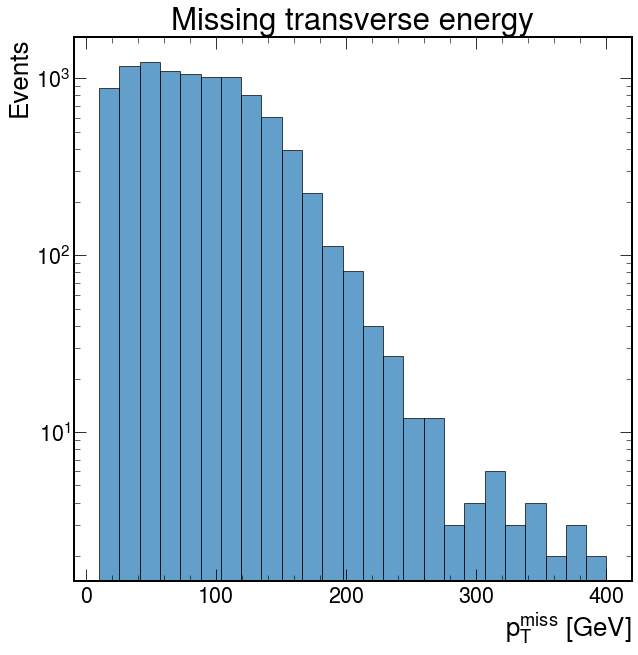

Uncomment and run after loading events.


In [34]:
# Plot MET for (up to) the first 10k events.
import mplhep as hep
hep.style.use("CMS")

# Your code:
met = events.MET.pt[:10_000]
plt.figure()
plt.hist(ak.to_numpy(met), bins=25, range=(10, 400), edgecolor="black", alpha=0.7)
plt.yscale('log')
plt.xlabel("p$_{T}^{miss}$ [GeV]")
plt.ylabel("Events")
plt.title("Missing transverse energy")
plt.show()

print("Uncomment and run after loading events.")

### Triggers in CMS

- **Definition**: Triggers are *online* selections applied by the CMS detector in real time to decide which events to keep.

- **Why they exist**: Not every collision can be stored, so CMS uses fast criteria (e.g. high MET, energetic electron/muon, high-pT photon) to retain interesting events.

- **Where they live in NanoAOD**: `events.HLT` contains **one boolean per HLT path** (`True` if that path fired in the event).

- **What we do in this exercise**: We require that **at least one** of a predefined set of analysis HLT paths (MET / single-electron / single-muon / photon) fired. This is the **first selection cut** and is applied to **both data and simulation**.

### Exercise 1.3 — Trigger OR

Build the trigger OR mask from `events.HLT` using the configured trigger list, and print how many events pass.

Events passing at least one analysis trigger: 750425
  run=297047 lumi=7 event=5293124 MET=161 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=6230854 MET=135 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5487432 MET=28 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=6054504 MET=26 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=6381858 MET=71 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5769909 MET=18 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5714999 MET=114 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5180131 MET=44 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5703384 MET=103 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=297047 lumi=7 event=5313190 MET=83 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight']


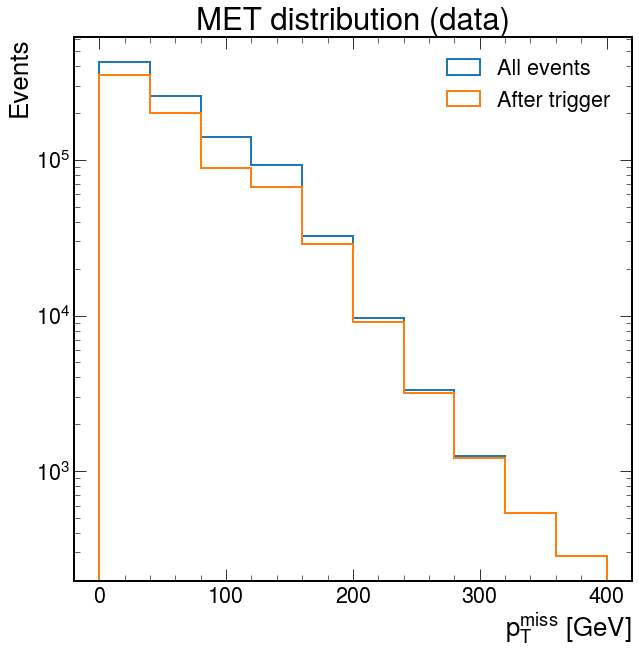

In [36]:
# Exercise 1.3: Trigger OR
# Build the trigger mask from the config list and events.HLT, then count events passing.
from config.datasets_2017 import get_trigger_list

trigger_list = get_trigger_list()
hlt_fields = set(events.HLT.fields) if hasattr(events, "HLT") and hasattr(events.HLT, "fields") else set()
trigger_mask = ak.zeros_like(events.event, dtype=bool)
for tname in trigger_list:
    if tname in hlt_fields:
        trigger_mask = trigger_mask | events.HLT[tname]
n_pass = int(ak.sum(trigger_mask))
print("Events passing at least one analysis trigger:", n_pass)

# Optional: inspect a few passing events
# passing = events_data[trigger_mask]
# n_show = min(10, len(passing))
# for i in range(n_show):
#     evi = passing[i]
#     fired = [t for t in trigger_list if t in evi.HLT.fields and evi.HLT[t]]
#     print(f"  run={evi.run} lumi={evi.luminosityBlock} event={evi.event} MET={evi.MET.pt:.0f} GeV  fired: {fired[:3]}{'...' if len(fired)>3 else ''}")
# print("Uncomment and run after loading events.")

# # Show a few passing events
passing = events_data[trigger_mask]
n_show = min(10, len(passing))
for i in range(n_show):
    evi = passing[i]
    fired = [t for t in trigger_list if (t in evi.HLT.fields and bool(evi.HLT[t]))]
    print(f"  run={int(evi.run)} lumi={int(evi.luminosityBlock)} event={int(evi.event)} MET={float(evi.MET.pt):.0f} GeV  fired: {fired[:3]}{'...' if len(fired)>3 else ''}")

# MET plot (optionally after trigger)
# met = events_data.MET.pt[:10_000]
# met_pass = passing.MET.pt[:10_000]
met = events_data.MET.pt
met_pass = passing.MET.pt

plt.figure()
plt.hist(ak.to_numpy(met), bins=10, range=(0, 400), histtype="step", linewidth=2, label="All events")
plt.hist(ak.to_numpy(met_pass), bins=10, range=(0, 400), histtype="step", linewidth=2, label="After trigger")
plt.xlabel("p$_{T}^{miss}$ [GeV]")
plt.ylabel("Events")
plt.title("MET distribution (data)")
plt.yscale("log")
plt.legend()
plt.show()

### Exercise 1.4 — Jet pT
Fill a histogram of **jet pT** for all jets in your sample. Use `events.Jet.pt`, flatten with `ak.flatten(events.Jet.pt)`, and plot with matplotlib. Use bins from 0 to 500 GeV.

Text(0.5, 1.0, 'Jet')

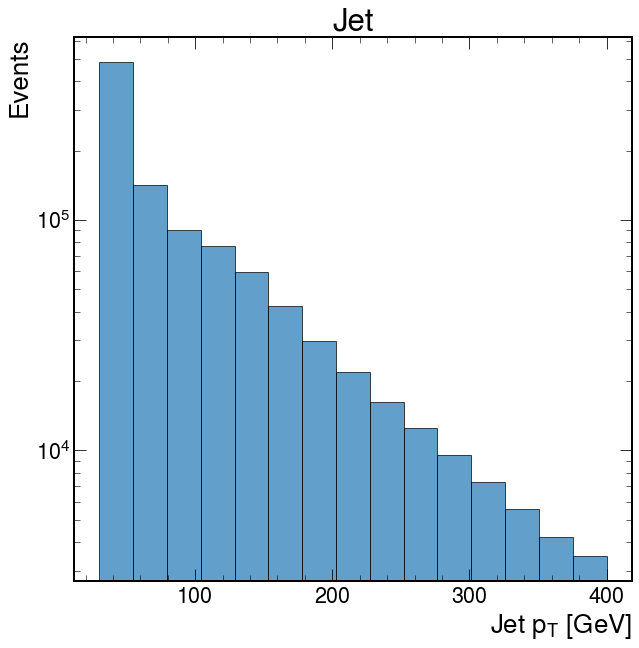

In [39]:
# Exercise 1.4 — Jet pT
# Example: compute flattened jet pt
jpt = ak.flatten(events.Jet.pt)
plt.figure()
plt.hist(ak.to_numpy(jpt), bins=15, range=(30, 400), edgecolor="black", alpha=0.7)
plt.yscale('log')
plt.xlabel("Jet p$_{T}$ [GeV]")
plt.ylabel("Events")
plt.title("Jet")
# TODO: add a histogram of jpt with matplotlib.

### Exercise 1.5 — Jet multiplicity
Plot the **number of jets per event** using `ak.num(events.Jet)`. Use bins from 0 to 15. Label axes and add a title.

Text(0.5, 1.0, 'Jet Mul')

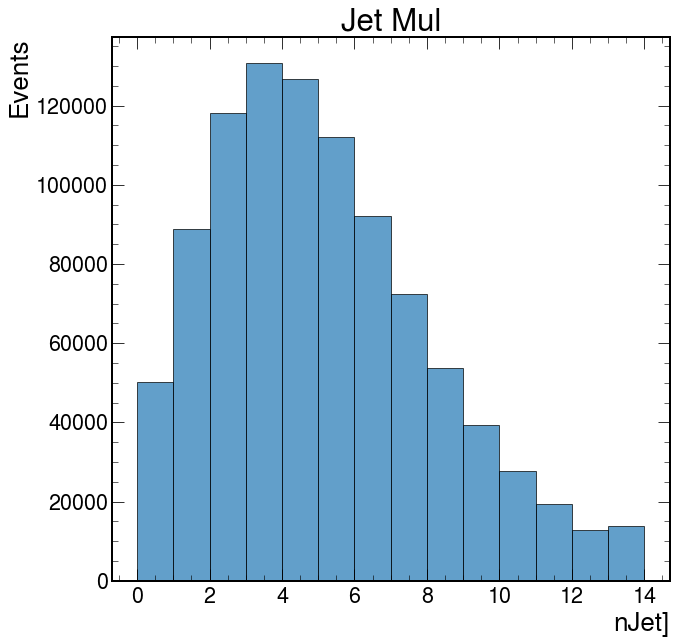

In [42]:
# Exercise 1.5 — Jet multiplicity
# Example: compute number of jets per event
njets = ak.num(events.Jet)
plt.figure()
plt.hist(ak.to_numpy(njets), bins=range(15), edgecolor="black", alpha=0.7)
plt.xlabel("nJet]")
plt.ylabel("Events")
plt.title("Jet Mul")
# TODO: make a histogram of njets.

### Exercise 1.6 — Lepton content
Inspect basic kinematics for electrons and muons using the loaded `events` object:
- Print the first few values of **pt, eta, and phi** for `events.Electron` and `events.Muon`.
- Count how many events have at least one electron or at least one muon.

In [ ]:
# Exercise 1.6 — Lepton content
# Example: inspect basic kinematics for electrons
print("Electron pt (first 5 events):", events.Electron.pt[:5])
# TODO: add prints for eta/phi and for muons, and counts of events with >=1 lepton.

### Exercise 1.7 — Lepton kinematic plots
Make histograms of **pt**, **eta**, and **phi** for electrons and muons:
- Use `ak.flatten(events.Electron.pt)` and `ak.flatten(events.Muon.pt)` for pt,
- Similarly flatten `eta` and `phi`.

Plot at least one distribution for electrons and one for muons.

In [ ]:
# Exercise 1.7 — Lepton kinematic plots
# Example: make one pt histogram for electrons
el_pt = ak.flatten(events.Electron.pt)
# TODO: add histograms for muon pt and for eta/phi.

---
## 10. Summary — Session 1

- **Dark matter** at colliders is searched for via MET and (in our case) b-jets.
- **NanoAOD** is a reduced ROOT format; we access it with **Coffea** and **Awkward Arrays**.
- **Loading:** `NanoEventsFactory.from_root({filepath: "Events"}, schemaclass=NanoAODSchema).events()`
- **Inspecting:** `events.Jet`, `events.MET`, etc.; use `ak.flatten` for per-object plots and `ak.num` for multiplicities.
- **Plotting:** Use matplotlib (or hist) with `ak.to_numpy()` for histogram inputs.

**Next session:** We will apply jet quality cuts, b-tagging, and lepton veto to define a clean object selection.